# 08 - Full Classical ML Benchmark: Test-Set Predictions for All 21 Configurations

`04_classical_ml.ipynb` compared 7 handcrafted features x 3 classifiers = **21
configurations** on the *validation* set, then only carried the single winner
(Histogram + SVM) forward to a test-set evaluation. `06_model_testing.ipynb` only
finalized that one winner.

For the web demo, every one of the 21 classical configurations needs to be
selectable, which means each one needs an actual **test-set prediction (label +
confidence) for every one of the 715 test images**, plus its own saved model. This
notebook produces exactly that.

### What this notebook does

1. Rebuilds the same train/validation/test split used everywhere else in this
   project (same seed).
2. Extracts all 7 feature representations once (Raw Pixels, Histogram, Sobel,
   Canny, LBP, HOG, GLCM), caching each so it's reused across its 3 classifiers.
3. Trains all 21 (feature x classifier) pipelines on train+validation combined
   (same approach as notebook 04's final evaluation), and evaluates each once on
   the held-out test set.
4. Saves every trained pipeline to `../models/classical/`.
5. Saves a **long-format** table of every (image, configuration) prediction to
   `../results/predictions/classical_test_predictions.csv` (715 x 21 = 15,015
   rows) - this is what the web export notebook will pivot into the site's JSON.
6. Saves an aggregate metrics table (accuracy/precision/recall/F1/ROC AUC per
   configuration, computed on the test set) to
   `../results/metrics/classical_full_test_results.csv`.

### A note on "confidence"

Logistic Regression and Random Forest expose `predict_proba` directly, so their
confidence is `max(predicted class probability)`. SVM here is trained **without**
`probability=True` (that calibration requires an expensive internal 5-fold CV per
model x 21 models would be slow) - instead its confidence is a monotonic transform
of the decision margin: `sigmoid(|decision_function|)`. This is not a formally
calibrated probability, but it is a reasonable, fast, and honestly-labeled stand-in
for "how far past the decision boundary this prediction is" - and it is documented
as such on the web page's model info panel.

### Expected runtime

Feature extraction + training + evaluation for all 21 configurations should take
roughly 10-20 minutes on CPU (much lighter than the deep learning notebooks - no
epochs, no backprop).

## 1. Imports

In [1]:
import gc
import sys
import time
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torchvision import datasets

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

sys.path.append(str(Path.cwd().parent))

from src.features.histogram import extract_histogram
from src.features.texture import extract_lbp, extract_glcm
from src.features.hog import extract_hog

## 2. Paths, Config, and Split (identical to notebooks 02 / 04 / 06 / 07)

In [2]:
SEED = 42
IMG_SIZE = 224
VAL_RATIO = 0.2

DATA_DIR = Path("../data/raw/casting_data/casting_data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

MODELS_DIR = Path("../models/classical")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

PREDICTIONS_DIR = Path("../results/predictions")
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

METRICS_DIR = Path("../results/metrics")
METRICS_DIR.mkdir(parents=True, exist_ok=True)

base_train_data = datasets.ImageFolder(TRAIN_DIR)
base_test_data = datasets.ImageFolder(TEST_DIR)

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(base_train_data), generator=generator).tolist()
val_size = int(len(indices) * VAL_RATIO)
val_indices = indices[:val_size]
train_indices = indices[val_size:]

all_paths = [Path(p) for p, _ in base_train_data.samples]
all_labels = [label for _, label in base_train_data.samples]

train_paths = [all_paths[i] for i in train_indices]
val_paths = [all_paths[i] for i in val_indices]
train_labels = [all_labels[i] for i in train_indices]
val_labels = [all_labels[i] for i in val_indices]

test_paths = [Path(p) for p, _ in base_test_data.samples]
test_labels = [label for _, label in base_test_data.samples]

print("Train:", len(train_paths), "Val:", len(val_paths), "Test:", len(test_paths))

Train: 5256 Val: 1313 Test: 715


## 3. Feature Extractors (identical to `04_classical_ml.ipynb`)

In [3]:
def load_image(path):
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"Could not read image: {path}")
    return cv2.resize(image, (IMG_SIZE, IMG_SIZE))


# Raw Pixels gets its own, much smaller resolution - see the note in section 5
# for why. Every other feature extractor below still works off the full
# IMG_SIZE=224 image returned by load_image(), unchanged.
RAW_PIXEL_SIZE = 64


def extract_raw_pixels(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    small = cv2.resize(gray, (RAW_PIXEL_SIZE, RAW_PIXEL_SIZE), interpolation=cv2.INTER_AREA)
    return small.flatten().astype(np.float32) / 255.0


def extract_sobel_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    sobel_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    magnitude = cv2.magnitude(sobel_x, sobel_y)

    features = [
        magnitude.mean(), magnitude.std(), magnitude.min(), magnitude.max(),
        np.percentile(magnitude, 25), np.percentile(magnitude, 50),
        np.percentile(magnitude, 75), np.percentile(magnitude, 90),
        np.percentile(magnitude, 95),
    ]
    return np.array(features, dtype=np.float32)


def extract_canny_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    edge_ratio = np.mean(edges > 0)
    features = [edge_ratio, edges.mean(), edges.std()]
    return np.array(features, dtype=np.float32)


FEATURE_EXTRACTORS = {
    "Raw Pixels": extract_raw_pixels,
    "Histogram": extract_histogram,
    "Sobel": extract_sobel_features,
    "Canny": extract_canny_features,
    "LBP": extract_lbp,
    "HOG": extract_hog,
    "GLCM": extract_glcm,
}

list(FEATURE_EXTRACTORS.keys())

['Raw Pixels', 'Histogram', 'Sobel', 'Canny', 'LBP', 'HOG', 'GLCM']

## 4. Classifiers (identical to `04_classical_ml.ipynb`)

In [4]:
def create_models():
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=SEED)),
        ]),
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", random_state=SEED)),
        ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, random_state=SEED, n_jobs=-1
        ),
    }


def get_final_estimator(pipeline):
    return pipeline.steps[-1][1] if hasattr(pipeline, "steps") else pipeline


def predict_with_confidence(pipeline, X):
    """Return (predicted_label, confidence in [0.5, 1.0]) for every row of X."""
    predictions = pipeline.predict(X)
    estimator = get_final_estimator(pipeline)

    if isinstance(estimator, SVC):
        margin = pipeline.decision_function(X)
        confidence = 1 / (1 + np.exp(-np.abs(margin)))
    else:
        proba = pipeline.predict_proba(X)
        confidence = proba.max(axis=1)

    return predictions, confidence


def positive_class_score(pipeline, X):
    """Score oriented so that higher = more confident in class 1 (ok_front),
    for a correctly-oriented ROC AUC regardless of classifier type."""
    estimator = get_final_estimator(pipeline)

    if isinstance(estimator, SVC):
        return pipeline.decision_function(X)

    proba = pipeline.predict_proba(X)
    classes = list(estimator.classes_)
    return proba[:, classes.index(1)]

## 5. Extract, Train, and Save - One Feature at a Time

**Two separate memory problems showed up here, on a real machine, one after the
other - both are fixed below.**

**Problem 1: caching all 7 features at once.** The original version extracted
all 7 feature representations for the whole dataset up front, before training
anything, so every feature matrix was in memory simultaneously. Fine for the
small hand-crafted features (Histogram, Sobel, Canny, LBP, GLCM, even HOG), but
Raw Pixels at the full `224*224` = 50,176-dimensional vector per image adds up
to roughly 1.5 GB across all 7,284 images on its own. *Fix:* process **one
feature at a time** - extract it (built directly on train+validation combined,
so there's no separate `X_train`/`X_val` that then get concatenated into a
*third* copy), train and save all 3 classifiers for it, then explicitly free
that feature's arrays (`del` + `gc.collect()`) before moving to the next
feature. At most one feature's data is in memory at once, instead of all 7.

**Problem 2: scikit-learn silently doubles Raw Pixels in memory anyway.** Even
with only one feature cached, `LogisticRegression` and `SVC` still crashed on
Raw Pixels specifically. Both solvers are hard-coded (inside scikit-learn
itself, not something `gc.collect()` or a dtype hint on our end can work around)
to convert their input to **float64** before fitting, regardless of what dtype
we hand them - `float32 -> float64` doubles the memory for that one array. At
50,176 dimensions x 6,569 training images, that single internal conversion
needs about **2.5 GB in one allocation**, which is what actually crashed.
(`RandomForestClassifier` was never affected - scikit-learn's tree code works in
float32 natively.) *Fix:* Raw Pixels now extracts at a smaller
**`RAW_PIXEL_SIZE = 64`** (64x64 = 4,096 dimensions, resized down from the
224x224 image with `cv2.INTER_AREA`) instead of the full 224x224 resolution.
This is a real change to that one feature - "Raw Pixels" now means a 64x64
downsized image rather than the full-resolution one - but it still serves the
same purpose (a features-free baseline to compare the engineered features
against), keeps that float64 conversion under ~220 MB, and only affects this
one feature; every other feature extractor is untouched.

In [5]:
def build_feature_matrix(paths, extractor):
    return np.asarray(
        [extractor(load_image(p)) for p in tqdm(paths, leave=False)],
        dtype=np.float32,
    )


train_val_paths = train_paths + val_paths
train_val_labels = np.array(train_labels + val_labels)

prediction_rows = []
metric_rows = []

for feature_name, extractor in FEATURE_EXTRACTORS.items():
    print(f"=== {feature_name} ===")
    start = time.time()

    X_train_final = build_feature_matrix(train_val_paths, extractor)
    X_test = build_feature_matrix(test_paths, extractor)

    print(
        f"  shapes: train+val={X_train_final.shape} test={X_test.shape} "
        f"({time.time() - start:.1f}s extraction)"
    )

    for model_name, pipeline in create_models().items():

        config_id = f"{feature_name.lower().replace(' ', '_')}_{model_name.lower().replace(' ', '_')}"
        print(f"  Training: {feature_name} + {model_name} ({config_id})")

        start = time.time()
        pipeline.fit(X_train_final, train_val_labels)

        test_predictions, test_confidence = predict_with_confidence(pipeline, X_test)
        test_score = positive_class_score(pipeline, X_test)

        elapsed = time.time() - start

        # Per-image predictions (long format)
        for path, true_label, pred_label, confidence in zip(
            test_paths, test_labels, test_predictions, test_confidence
        ):
            prediction_rows.append({
                "image_path": str(path),
                "true_label": true_label,
                "feature": feature_name,
                "classifier": model_name,
                "config_id": config_id,
                "predicted_label": int(pred_label),
                "confidence": float(confidence),
            })

        # Aggregate metrics
        metric_rows.append({
            "config_id": config_id,
            "feature": feature_name,
            "classifier": model_name,
            "feature_dim": X_train_final.shape[1],
            "test_accuracy": accuracy_score(test_labels, test_predictions),
            "test_precision": precision_score(test_labels, test_predictions),
            "test_recall": recall_score(test_labels, test_predictions),
            "test_f1": f1_score(test_labels, test_predictions),
            "test_roc_auc": roc_auc_score(test_labels, test_score),
            "train_seconds": elapsed,
        })

        # Save the trained pipeline, then drop our reference so its memory
        # (in particular whatever the fitted StandardScaler/SVM/RandomForest
        # is holding onto) can be freed before the next classifier trains.
        joblib.dump(pipeline, MODELS_DIR / f"{config_id}.joblib")
        del pipeline

    # Done with this feature - free its arrays before extracting the next
    # one. This is the key difference from the original version, which
    # extracted and cached all 7 features before training anything, and is
    # what fixes the MemoryError.
    del X_train_final, X_test
    gc.collect()

print("Done. Trained and saved", len(metric_rows), "configurations.")

=== Raw Pixels ===


  shapes: train+val=(6569, 4096) test=(715, 4096) (6.0s extraction)
  Training: Raw Pixels + Logistic Regression (raw_pixels_logistic_regression)
  Training: Raw Pixels + SVM (raw_pixels_svm)
  Training: Raw Pixels + Random Forest (raw_pixels_random_forest)
=== Histogram ===


  shapes: train+val=(6569, 256) test=(715, 256) (5.2s extraction)
  Training: Histogram + Logistic Regression (histogram_logistic_regression)
  Training: Histogram + SVM (histogram_svm)
  Training: Histogram + Random Forest (histogram_random_forest)
=== Sobel ===


  shapes: train+val=(6569, 9) test=(715, 9) (28.9s extraction)
  Training: Sobel + Logistic Regression (sobel_logistic_regression)
  Training: Sobel + SVM (sobel_svm)
  Training: Sobel + Random Forest (sobel_random_forest)
=== Canny ===


  shapes: train+val=(6569, 3) test=(715, 3) (10.6s extraction)
  Training: Canny + Logistic Regression (canny_logistic_regression)
  Training: Canny + SVM (canny_svm)
  Training: Canny + Random Forest (canny_random_forest)
=== LBP ===


  shapes: train+val=(6569, 10) test=(715, 10) (60.4s extraction)
  Training: LBP + Logistic Regression (lbp_logistic_regression)
  Training: LBP + SVM (lbp_svm)
  Training: LBP + Random Forest (lbp_random_forest)
=== HOG ===


  shapes: train+val=(6569, 6084) test=(715, 6084) (59.4s extraction)
  Training: HOG + Logistic Regression (hog_logistic_regression)
  Training: HOG + SVM (hog_svm)
  Training: HOG + Random Forest (hog_random_forest)
=== GLCM ===


  shapes: train+val=(6569, 5) test=(715, 5) (9.0s extraction)
  Training: GLCM + Logistic Regression (glcm_logistic_regression)
  Training: GLCM + SVM (glcm_svm)
  Training: GLCM + Random Forest (glcm_random_forest)
Done. Trained and saved 21 configurations.


## 7. Save Predictions and Metrics

In [6]:
predictions_df = pd.DataFrame(prediction_rows)
predictions_df.to_csv(PREDICTIONS_DIR / "classical_test_predictions.csv", index=False)
print("Saved:", (PREDICTIONS_DIR / "classical_test_predictions.csv").resolve())
print("Rows:", len(predictions_df))

metrics_df = pd.DataFrame(metric_rows).sort_values("test_f1", ascending=False).reset_index(drop=True)
metrics_df.to_csv(METRICS_DIR / "classical_full_test_results.csv", index=False)
print("Saved:", (METRICS_DIR / "classical_full_test_results.csv").resolve())

metrics_df

Saved: D:\Casting Quality Inspection\results\predictions\classical_test_predictions.csv
Rows: 15015
Saved: D:\Casting Quality Inspection\results\metrics\classical_full_test_results.csv


,config_id,feature,classifier,feature_dim,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,train_seconds
0,histogram_svm,Histogram,SVM,256,0.998601,1.000000,0.996183,0.998088,1.000000,1.090580
1,histogram_random_forest,Histogram,Random Forest,256,0.993007,0.996139,0.984733,0.990403,0.999773,2.030319
2,raw_pixels_svm,Raw Pixels,SVM,4096,0.988811,0.984733,0.984733,0.984733,0.996579,60.516650
3,hog_svm,HOG,SVM,6084,0.986014,0.980916,0.980916,0.980916,0.999065,166.622261
4,raw_pixels_random_forest,Raw Pixels,Random Forest,4096,0.976224,0.969349,0.965649,0.967495,0.996592,8.858463
5,hog_random_forest,HOG,Random Forest,6084,0.972028,0.984000,0.938931,0.960938,0.997477,12.606390
6,hog_logistic_regression,HOG,Logistic Regression,6084,0.969231,0.941176,0.977099,0.958801,0.993782,3.921621
7,histogram_logistic_regression,Histogram,Logistic Regression,256,0.951049,0.967078,0.896947,0.930693,0.987808,0.292576
8,sobel_svm,Sobel,SVM,9,0.918881,0.859155,0.931298,0.893773,0.962852,0.730714
9,sobel_random_forest,Sobel,Random Forest,9,0.927273,0.968750,0.828244,0.893004,0.991499,0.663220


## 8. Sanity-Check Chart

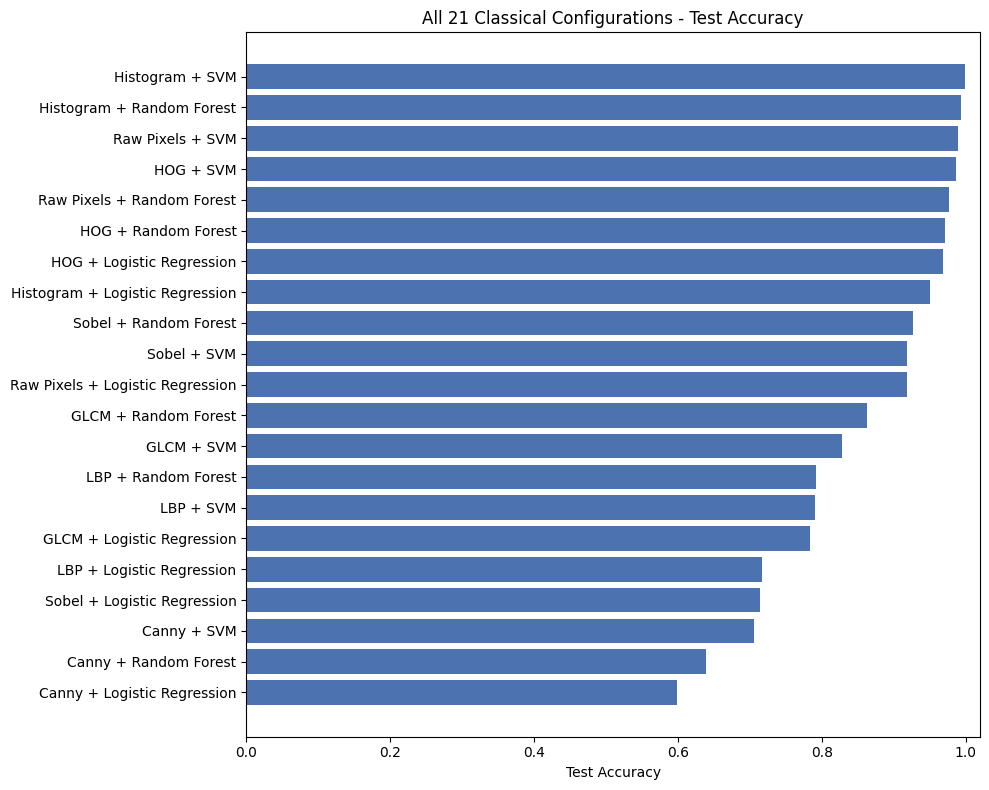

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

plot_df = metrics_df.sort_values("test_accuracy")
labels = plot_df["feature"] + " + " + plot_df["classifier"]

ax.barh(labels, plot_df["test_accuracy"], color="#4C72B0")
ax.set_xlabel("Test Accuracy")
ax.set_title("All 21 Classical Configurations - Test Accuracy")
ax.set_xlim(0, 1.02)

plt.tight_layout()
plt.show()

## 9. Summary

- All 21 (feature x classifier) configurations are now trained on train+validation
  and evaluated once on the untouched test set - not just the single best one.
- 21 trained pipelines are saved to `../models/classical/`.
- Per-image predictions for all 21 configurations x 715 test images are saved to
  `../results/predictions/classical_test_predictions.csv` (long format).
- Aggregate test metrics for all 21 configurations are saved to
  `../results/metrics/classical_full_test_results.csv`.

### Next step

EfficientNet-B0 was dropped from this project (it crashed the kernel while
training on this machine, and ResNet18 already had a finalized checkpoint -
see `src/inference/registry.py`'s module docstring for the full reasoning),
so the model lineup is now 21 classical configurations + ResNet18 = 22
models, not 23. `09_export_web_assets.ipynb` combines this notebook's output
with `06_model_testing.ipynb`'s ResNet18 checkpoint into the JSON + image
assets the static web demo will read.